In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/labeled_dataset.csv")

In [3]:
df.head()

,age,gender,height_cm,weight_kg,bmi,bmi_category,condition,ckd_stage,dialysis_type,diabetes_type,...,carbs_g,sugar_g,fiber_g,sodium_mg,potassium_mg,phosphorus_mg,gi_value,gi_category,gi_match_type,label
0,23,male,161,129.2,49.8,obese,diabetes,NaN,NaN,type2,...,72.83,0.00,3.9,1.0,186.0,136.0,50.0,unknown,unmatched,moderate
1,76,male,186,68.8,19.9,normal,hypertension,NaN,NaN,NaN,...,3.00,0.00,2.9,111.0,6.0,19.0,50.0,unknown,unmatched,safe
2,53,male,161,85.6,33.0,obese,hypertension,NaN,NaN,NaN,...,72.20,1.10,2.4,2.0,128.0,119.0,50.0,unknown,unmatched,safe
3,73,male,158,81.7,32.7,obese,kidney_disease,3.0,NaN,NaN,...,10.80,6.98,2.8,1.0,130.0,12.0,50.0,unknown,unmatched,safe
4,59,female,149,96.8,43.6,obese,diabetes,NaN,NaN,type2,...,7.53,0.00,0.0,1127.0,225.0,129.0,50.0,unknown,unmatched,moderate


In [4]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (10000, 40)

Columns: ['age', 'gender', 'height_cm', 'weight_kg', 'bmi', 'bmi_category', 'condition', 'ckd_stage', 'dialysis_type', 'diabetes_type', 'comorbidity', 'medication', 'activity_level', 'food_name', 'canonical_name', 'food_category', 'preparation_state', 'cooking_method', 'fat_descriptor', 'bone_status', 'enrichment', 'special_population', 'source', 'brand', 'cuisine', 'is_composite_dish', 'serving_size_g', 'calories', 'protein_g', 'fat_g', 'carbs_g', 'sugar_g', 'fiber_g', 'sodium_mg', 'potassium_mg', 'phosphorus_mg', 'gi_value', 'gi_category', 'gi_match_type', 'label']

Data types:
 age                     int64
gender                 object
height_cm               int64
weight_kg             float64
bmi                   float64
bmi_category           object
condition              object
ckd_stage             float64
dialysis_type          object
diabetes_type          object
comorbidity            object
medication             object
activity_level         object
fo

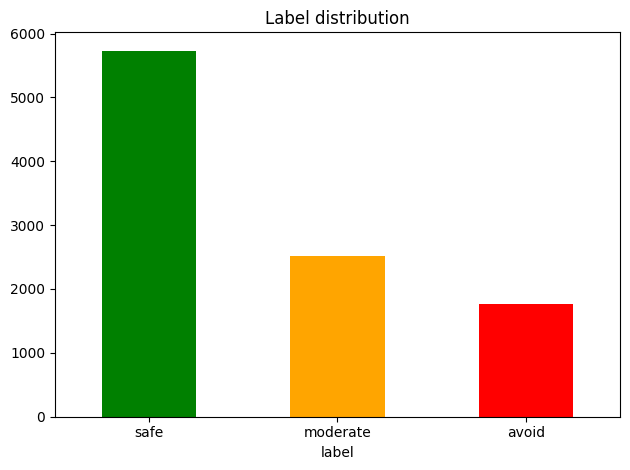

In [5]:
# Label distribution
df['label'].value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title("Label distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../data/diagrams/label_distribution.png")
plt.show()

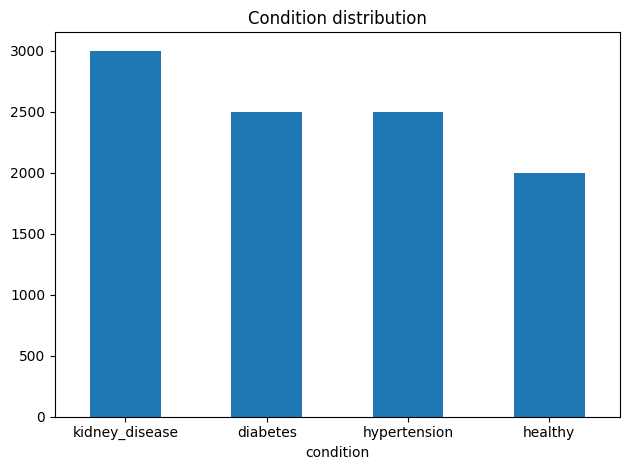

In [6]:
# Condition distribution
df['condition'].value_counts().plot(kind='bar')
plt.title("Condition distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

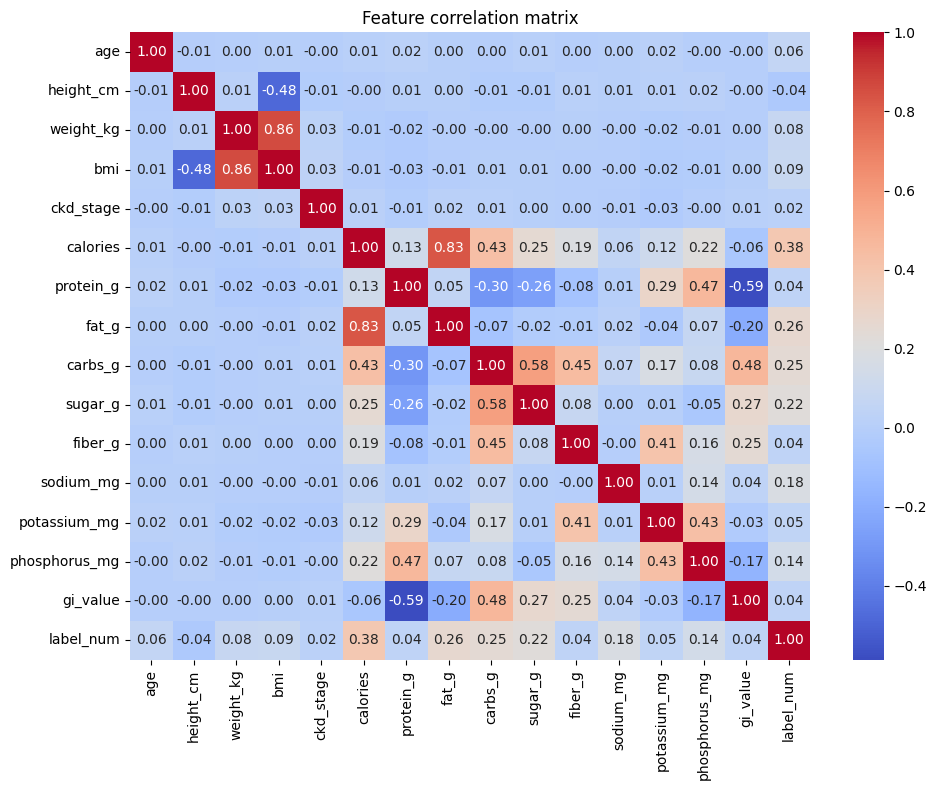

In [10]:
# Feature correlations with label
# Encode label numerically for correlation
df['label_num'] = df['label'].map({'safe': 0, 'moderate': 1, 'avoid': 2})

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = numeric_cols.drop('serving_size_g')  # Exclude label_num from correlation

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("../data/diagrams/correlation_matrix.png")
plt.show()